## Imports Libaries

In [2]:
#  Suppress Warnings
import warnings
import logging
import tensorflow as tf 
warnings.filterwarnings("ignore", category=UserWarning, module="transformers")
tf.get_logger().setLevel(logging.ERROR)  # Suppress TensorFlow warnings

#  Standard Libraries
import re
import ast
import wikipedia
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from collections import Counter

#  Natural Language Processing (NLP)
import nltk
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.sentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
import spacy
from sentence_transformers import SentenceTransformer, util

#  Topic Modeling & Feature Extraction
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from bertopic import BERTopic
from gensim import corpora, models
import gensim

#  Deep Learning & Transformers
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from transformers import (
    T5ForConditionalGeneration, 
    T5Tokenizer, 
    GPT2LMHeadModel, 
    GPT2Tokenizer
)

#  Machine Learning
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.manifold import TSNE

#  PyTorch for Transformers
import torch

#  Download required NLTK data
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('vader_lexicon')
nltk.download('omw-1.4')

#  Initialize T5 Tokenizer (Prevents legacy behavior warning)
t5_tokenizer = T5Tokenizer.from_pretrained('t5-small', legacy=False)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\300384334\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\300384334\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\300384334\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\300384334\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## All Def Function 

In [4]:
# Define column names (adjust these if your CSV uses different names)
TEXT_COLUMN = 'content'      # Text content column name
DATE_COLUMN = 'date'         # Date column name (if available)
CATEGORY_COLUMN = 'category' # Category column name (if available)

In [5]:
# Load dataset and drop rows with missing TEXT_COLUMN
df = pd.read_csv('bbc_news_articles_scrapy.csv')
df = df.dropna(subset=[TEXT_COLUMN])
print("Dataset loaded. Number of articles:", len(df))

Dataset loaded. Number of articles: 161


In [6]:
# Define function to clean text (lowercase, remove punctuation, extra whitespace)
def clean_text(text):
    """Clean text by lowercasing, removing punctuation, and extra whitespace."""
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [7]:
# Define function to apply Porter Stemming and WordNet Lemmatization
def stem_and_lemmatize(text):
    """Apply Porter Stemming and WordNet Lemmatization to the text."""
    tokens = nltk.word_tokenize(text)
    stemmer = PorterStemmer()
    lemmatizer = WordNetLemmatizer()
    stemmed = [stemmer.stem(token) for token in tokens]
    lemmatized = [lemmatizer.lemmatize(token) for token in tokens]
    return ' '.join(stemmed), ' '.join(lemmatized)

In [8]:
# Define function for sentiment analysis using TextBlob and NLTK VADER
def analyze_sentiment(text):
    """Perform sentiment analysis using TextBlob and NLTK's VADER."""
    blob = TextBlob(text)
    tb_sentiment = blob.sentiment
    sia = SentimentIntensityAnalyzer()
    nltk_sentiment = sia.polarity_scores(text)
    return tb_sentiment, nltk_sentiment

In [9]:
# Define function to extract features using CountVectorizer and TF-IDF
def extract_features(corpus):
    """Extract features using CountVectorizer and TfidfVectorizer."""
    count_vect = CountVectorizer()
    tfidf_vect = TfidfVectorizer()
    count_features = count_vect.fit_transform(corpus)
    tfidf_features = tfidf_vect.fit_transform(corpus)
    return count_features, tfidf_features, count_vect, tfidf_vect

In [10]:
# Define function for BERTopic topic modeling
def perform_bertopic(corpus):
    """Perform topic modeling using BERTopic and return topics and probabilities."""
    topic_model = BERTopic(verbose=False)
    topics, probs = topic_model.fit_transform(corpus)
    return topic_model, topics, probs

In [11]:
# Define function for text summarization using T5 Transformers
def summarize_text(text):
    """Summarize text using T5 Transformers model."""
    tokenizer = T5Tokenizer.from_pretrained('t5-small')
    model = T5ForConditionalGeneration.from_pretrained('t5-small')
    input_text = "summarize: " + text
    input_ids = tokenizer.encode(input_text, return_tensors='pt', max_length=512, truncation=True)
    summary_ids = model.generate(input_ids, max_length=150, min_length=40, length_penalty=5.0, num_beams=2)
    summary = tokenizer.decode(summary_ids[0], skip_special_tokens=True)
    return summary

In [12]:
# Define function for Named Entity Recognition (NER) using spaCy Transformers
def perform_ner(text):
    """Perform Named Entity Recognition using spaCy Transformers."""
    nlp = spacy.load('en_core_web_trf')
    doc = nlp(text)
    entities = [(ent.text, ent.label_) for ent in doc.ents]
    return entities

In [13]:
# Define function to build an autoencoder for anomaly detection (TensorFlow)
def build_autoencoder(input_dim):
    """Build and compile a simple autoencoder model for anomaly detection."""
    input_layer = Input(shape=(input_dim,))
    encoded = Dense(64, activation='relu')(input_layer)
    encoded = Dense(32, activation='relu')(encoded)
    decoded = Dense(64, activation='relu')(encoded)
    decoded = Dense(input_dim, activation='sigmoid')(decoded)
    autoencoder = Model(input_layer, decoded)
    autoencoder.compile(optimizer='adam', loss='mse')
    return autoencoder

In [14]:
# Define function to detect anomalies using autoencoder reconstruction error
def detect_anomalies(autoencoder, data, threshold=0.1):
    """Detect anomalies based on autoencoder reconstruction error exceeding threshold."""
    reconstructions = autoencoder.predict(data)
    reconstruction_error = np.mean(np.square(data - reconstructions), axis=1)
    anomalies = reconstruction_error > threshold
    return anomalies, reconstruction_error

In [15]:
# Define function for LDA topic extraction using Gensim and assign document topics
def perform_lda(corpus, num_topics=5):
    """Perform LDA topic extraction using Gensim and return document topics."""
    texts = [doc.split() for doc in corpus]
    dictionary = corpora.Dictionary(texts)
    corpus_gensim = [dictionary.doc2bow(text) for text in texts]
    lda_model = models.LdaModel(corpus_gensim, num_topics=num_topics, id2word=dictionary, passes=10)
    # Assign each document its most probable topic
    doc_topics = [max(lda_model.get_document_topics(bow), key=lambda x: x[1])[0] for bow in corpus_gensim]
    return lda_model, doc_topics

In [16]:
# Define function to compute BERT embeddings and cosine similarity (for demo purposes)
def compute_bert_similarity(texts):
    """Compute BERT embeddings for texts and calculate cosine similarity matrix."""
    model = SentenceTransformer('all-MiniLM-L6-v2')
    embeddings = model.encode(texts, convert_to_tensor=True)
    cosine_scores = util.cos_sim(embeddings, embeddings)
    return cosine_scores

In [17]:
# Define function to link a named entity to its Wikipedia summary
def link_entity_to_wikipedia(entity):
    """Link named entity to its Wikipedia summary using Wikipedia API."""
    try:
        summary = wikipedia.summary(entity, sentences=1)
    except Exception:
        summary = "No summary found"
    return summary

In [18]:
# Define function to cluster texts using K-Means and Agglomerative Clustering
def cluster_texts(features, n_clusters=5):
    """Cluster texts using K-Means and Agglomerative Clustering on feature matrix."""
    kmeans = KMeans(n_clusters=n_clusters, random_state=42).fit(features)
    data_array = features.toarray() if hasattr(features, 'toarray') else features
    agglo = AgglomerativeClustering(n_clusters=n_clusters).fit(data_array)
    return kmeans.labels_, agglo.labels_

In [19]:
# Define function to plot sentiment trend over time (if DATE_COLUMN exists)
def plot_sentiment_trend(dates, sentiments):
    """Plot sentiment trend over time using matplotlib."""
    plt.figure(figsize=(10,5))
    plt.plot(dates, sentiments, marker='o')
    plt.title("Sentiment Trend Over Time")
    plt.xlabel("Date")
    plt.ylabel("Sentiment")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [20]:
# Define a simple placeholder GNN model for text classification
def build_simple_gnn(input_dim, num_classes):
    """Build a simple GNN model for text classification (using dense layers as a proxy)."""
    model = tf.keras.Sequential([
        Dense(64, activation='relu', input_shape=(input_dim,)),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [21]:
def build_lstm_model(vocab_size, embedding_dim, input_length):
    """Build and compile a simple LSTM model for sentiment analysis."""
    model = tf.keras.Sequential([
        tf.keras.layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=input_length),
        tf.keras.layers.LSTM(64),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    
    # Explicitly build the model with a sample input shape
    model.build(input_shape=(None, input_length))
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [22]:
# Load pre-trained GPT-2 model and tokenizer once to avoid reloading every time
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2")
# Explicitly set the pad token to avoid warnings
tokenizer.pad_token = tokenizer.eos_token

def generate_text(prompt, max_length=50):
    """Generate text using GPT-2 based on a given prompt."""
    # Tokenize input with padding and truncation
    input_ids = tokenizer(prompt, return_tensors="pt", padding=True, truncation=True)
    output = model.generate(
        input_ids["input_ids"], 
        attention_mask=input_ids["attention_mask"],  # Ensure attention mask is set
        max_length=max_length,
        num_return_sequences=1,
        no_repeat_ngram_size=2, 
        do_sample=True,
        pad_token_id=tokenizer.pad_token_id  # Set pad token ID to avoid warnings
    )
    generated_text = tokenizer.decode(output[0], skip_special_tokens=True)
    return generated_text

# Example usage
print(generate_text("Artificial Intelligence is"))

Artificial Intelligence is not alone in this area. Researchers will begin investigating the AI market in a few months.

In April, Microsoft, Twitter, the U.S. Securities and Exchange Commission, and Facebook announced that they're collaborating with C


## Main function 
### > Process all rows and add separate columns for each model output; then write final CSV

In [24]:
def main():
    # Clean and normalize text from TEXT_COLUMN
    df['clean_text'] = df['content'].apply(clean_text)

    # Apply stemming and lemmatization; store results in separate columns
    df['stemmed'], df['lemmatized'] = zip(*df['clean_text'].apply(stem_and_lemmatize))

    # Perform sentiment analysis; store TextBlob and NLTK VADER results in separate columns
    df['tb_sentiment'] = df['clean_text'].apply(lambda x: analyze_sentiment(x)[0])
    df['nltk_sentiment'] = df['clean_text'].apply(lambda x: analyze_sentiment(x)[1])

    # Extract text features using CountVectorizer and TF-IDF
    count_features, tfidf_features, count_vect, tfidf_vect = extract_features(df['clean_text'])

    # Perform BERTopic topic modeling and store per-document topic in a new column
    topic_model, bertopic_topics, probs = perform_bertopic(df['clean_text'].tolist())
    df['bertopic_topic'] = bertopic_topics

    # Generate text summary for each article and store in a new column (this may take some time)
    df['summary'] = df['clean_text'].apply(lambda x: summarize_text(x))

    # Extract Named Entities for each article and store in a new column
    df['entities'] = df['clean_text'].apply(lambda x: perform_ner(x))

    # Train an autoencoder on the entire TF-IDF matrix and detect anomalies; add the anomaly flag as a column
    autoencoder = build_autoencoder(tfidf_features.shape[1])
    autoencoder.fit(tfidf_features.toarray(), tfidf_features.toarray(), epochs=5, batch_size=16, verbose=0)
    anomalies, recon_error = detect_anomalies(autoencoder, tfidf_features.toarray())
    df['anomaly'] = anomalies

    # Perform LDA topic extraction and assign each document its most probable topic
    lda_model, lda_doc_topics = perform_lda(df['clean_text'].tolist(), num_topics=5)
    df['lda_topic'] = lda_doc_topics

    # Cluster texts using K-Means and Agglomerative Clustering; store cluster labels in new columns
    kmeans_labels, agglo_labels = cluster_texts(count_features, n_clusters=5)
    df['kmeans_cluster'] = kmeans_labels
    df['agglo_cluster'] = agglo_labels

    # (Optional) If DATE_COLUMN exists, convert to datetime and plot sentiment trend over time
    if DATE_COLUMN in df.columns:
        df['date'] = pd.to_datetime(df[DATE_COLUMN])
        df['sentiment'] = df['tb_sentiment'].apply(lambda x: x.polarity)
        df_sorted = df.sort_values('date')
        plot_sentiment_trend(df_sorted['date'], df_sorted['sentiment'])

    # Build and print summaries of deep learning models (GNN and LSTM) for reference (not added to df)
    num_classes = df[CATEGORY_COLUMN].nunique() if CATEGORY_COLUMN in df.columns else 5
    gnn_model = build_simple_gnn(count_features.shape[1], num_classes)
    print("GNN model summary:")
    gnn_model.summary()

    lstm_model = build_lstm_model(vocab_size=5000, embedding_dim=128, input_length=100)
    print("LSTM model summary:")
    lstm_model.summary()

    # Generate text using GPT-2 with a prompt (demo output)
    generated_text = generate_text("Breaking news", max_length=50)
    print("Generated text by GPT-2:", generated_text)

    # Save the final DataFrame with all new columns to a CSV file
    df.to_csv('advancedtextmining_bbc_news_articles_.csv', index=False)
    print("Final processed CSV saved as '/content/final_bbc_news_articles_processed.csv'.")

if __name__ == "__main__":
    main()

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
GNN model summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ (None, 64)                  │         407,744 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 5)                   │             325 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 408,069 (1.56 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 100, 128)            │         640,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 689,473 (2.63 MB)

 Trainable params: 689,473 (2.63 MB)

 Non-trainable params: 0 (0.00 B)

Generated text by GPT-2: Breaking news for the women who have become the latest targets of female predators on our land.
Final processed CSV saved as '/content/final_bbc_news_articles_processed.csv'.


In [25]:
 # Print final dataframe head to show added columns
df.head()

,title,url,content,clean_text,stemmed,lemmatized,tb_sentiment,nltk_sentiment,bertopic_topic,summary,entities,anomaly,lda_topic,kmeans_cluster,agglo_cluster
0,UK,https://www.bbc.com/news/england,"NHS bosses have admitted failing Carly Wesson,...",nhs bosses have admitted failing carly wesson ...,nh boss have admit fail carli wesson carl ever...,nh boss have admitted failing carly wesson car...,"(0.06358114108114107, 0.37430597180597175)","{'neg': 0.09, 'neu': 0.809, 'pos': 0.101, 'com...",5,nhs bosses admit failing carly wesson carl eve...,"[(nhs, ORG), (carly wesson, PERSON), (carl eve...",False,3,3,2
1,Wales,https://www.bbc.com/news/wales/wales_politics,House prices in a Welsh county have fallen by ...,house prices in a welsh county have fallen by ...,hous price in a welsh counti have fallen by mo...,house price in a welsh county have fallen by m...,"(0.11966089466089466, 0.31361832611832613)","{'neg': 0.032, 'neu': 0.89, 'pos': 0.078, 'com...",7,shadow secretary of state and senedd group lea...,"[(welsh, GPE), (more than yearonyear, DATE), (...",False,3,0,0
2,Conclave and The Brutalist win big at the Baftas,https://www.bbc.com/news/articles/cvge2gdle6ko,Pope drama Conclave and immigration epic The B...,pope drama conclave and immigration epic the b...,pope drama conclav and immigr epic the brutali...,pope drama conclave and immigration epic the b...,"(0.35566233766233757, 0.37346365129123726)","{'neg': 0.055, 'neu': 0.638, 'pos': 0.307, 'co...",2,pope drama conclave and immigration epic the b...,"[(pope drama conclave, WORK_OF_ART), (the baft...",False,1,3,1
3,Freezing rain and snow leads to multi-vehicle ...,https://www.bbc.com/news/videos/cx2q3vz7zgwo,A snow storm has caused chaos on an Oregon hig...,a snow storm has caused chaos on an oregon hig...,a snow storm ha caus chao on an oregon highway...,a snow storm ha caused chaos on an oregon high...,"(0.07739829614829616, 0.2813866688866689)","{'neg': 0.111, 'neu': 0.865, 'pos': 0.024, 'co...",8,a snow storm has caused chaos on an oregon hig...,"[(oregon, GPE), (up to, CARDINAL), (four, CARD...",False,0,0,0
4,Australia,https://www.bbc.com/news/world/australia,Canberra says a Chinese fighter jet released f...,canberra says a chinese fighter jet released f...,canberra say a chines fighter jet releas flare...,canberra say a chinese fighter jet released fl...,"(0.15891063411896744, 0.3802833894500561)","{'neg': 0.107, 'neu': 0.792, 'pos': 0.101, 'co...",0,chinese fighter jet released flares in front o...,"[(canberra, GPE), (chinese, NORP), (australian...",False,3,0,0


# Visualisation 

## Visualize Sentiment Distribution (TextBlob and NLTK Sentiment)

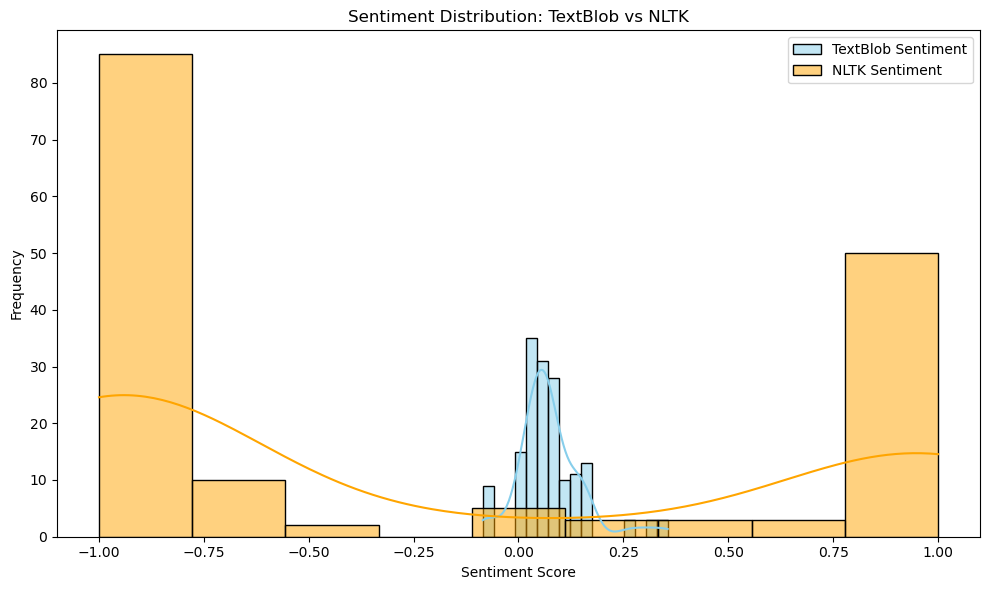

In [28]:
plt.figure(figsize=(10, 6))
sns.histplot(df['tb_sentiment'].apply(lambda x: x.polarity), kde=True, color='skyblue', label='TextBlob Sentiment')
sns.histplot(df['nltk_sentiment'].apply(lambda x: x['compound']), kde=True, color='orange', label='NLTK Sentiment')
plt.title('Sentiment Distribution: TextBlob vs NLTK')
plt.xlabel('Sentiment Score')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

## Visualize Distribution of Topics (BERTopic)

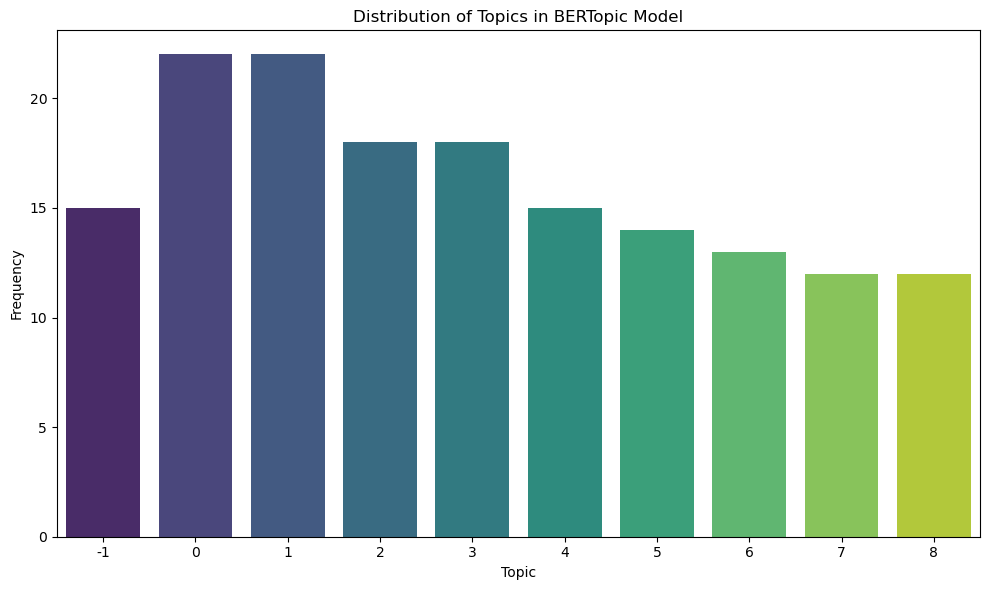

In [30]:
plt.figure(figsize=(10, 6))
sns.countplot(x=df['bertopic_topic'], palette='viridis')
plt.title('Distribution of Topics in BERTopic Model')
plt.xlabel('Topic')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## Visualize Distribution of LDA Topics

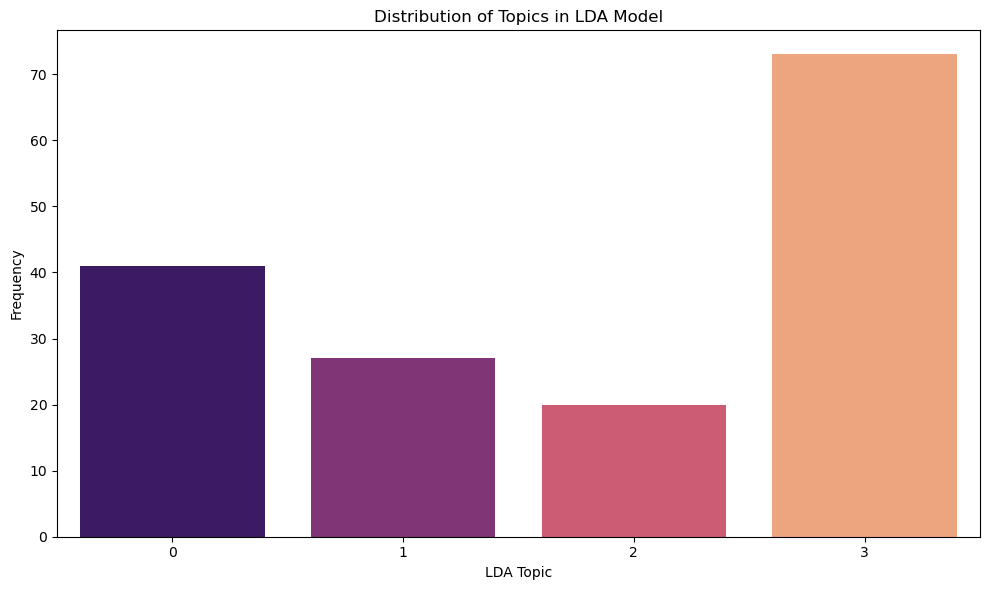

In [32]:
plt.figure(figsize=(10, 6))
sns.countplot(x=df['lda_topic'], palette='magma')
plt.title('Distribution of Topics in LDA Model')
plt.xlabel('LDA Topic')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## Visualizing Clustering (KMeans and Agglomerative Clustering

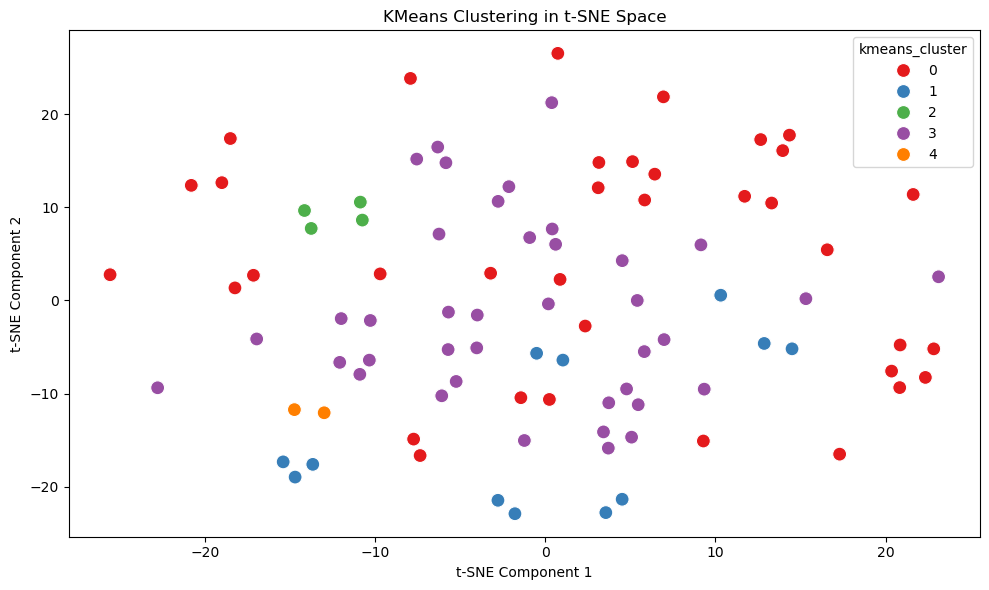

In [34]:
vectorizer = TfidfVectorizer(max_features=1000)  # You can adjust max_features as needed
tfidf_features = vectorizer.fit_transform(df['clean_text'])
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=300)
tsne_results = tsne.fit_transform(tfidf_features.toarray())  # .toarray() needed for sparse matrix

# Visualizing the KMeans clusters in t-SNE space
plt.figure(figsize=(10, 6))
sns.scatterplot(x=tsne_results[:, 0], y=tsne_results[:, 1], hue=df['kmeans_cluster'], palette='Set1', s=100)
plt.title('KMeans Clustering in t-SNE Space')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.tight_layout()
plt.show()

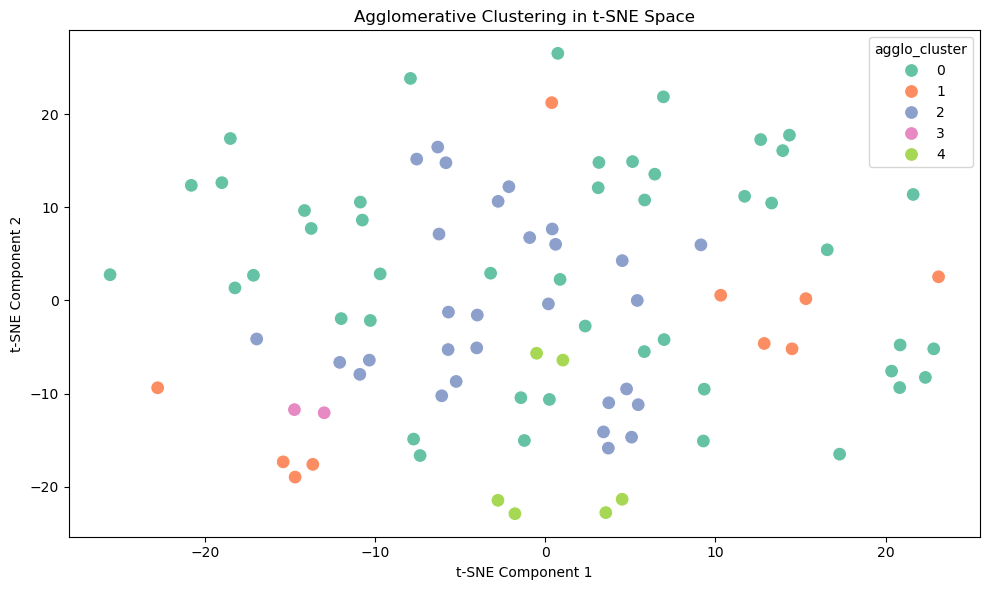

In [35]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=tsne_results[:, 0], y=tsne_results[:, 1], hue=df['agglo_cluster'], palette='Set2', s=100)
plt.title('Agglomerative Clustering in t-SNE Space')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.tight_layout()
plt.show()

## Clustering Distribution (KMeans & Agglomerative)

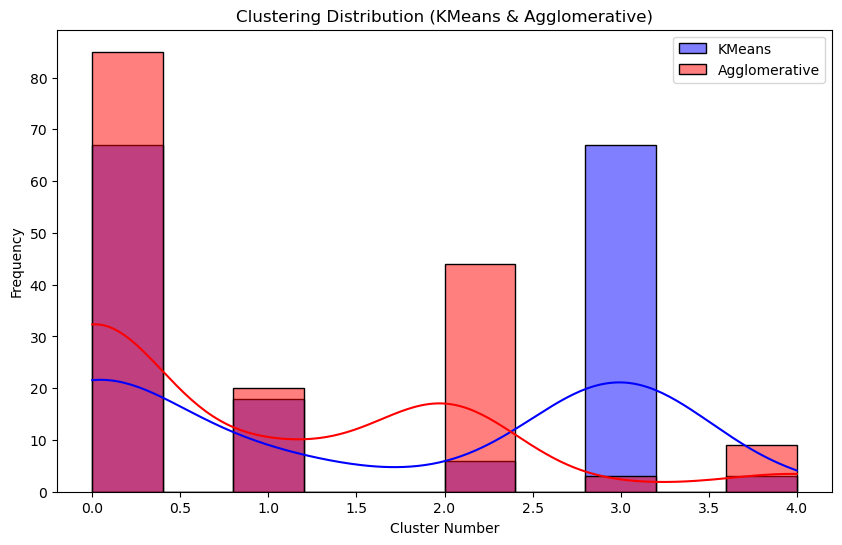

In [37]:
plt.figure(figsize=(10, 6))
sns.histplot(df['kmeans_cluster'], bins=10, kde=True, color='blue', label='KMeans')
sns.histplot(df['agglo_cluster'], bins=10, kde=True, color='red', label='Agglomerative', alpha=0.5)
plt.title('Clustering Distribution (KMeans & Agglomerative)')
plt.xlabel('Cluster Number')
plt.ylabel('Frequency')
plt.legend()
plt.show()

## Anomaly Detection Count

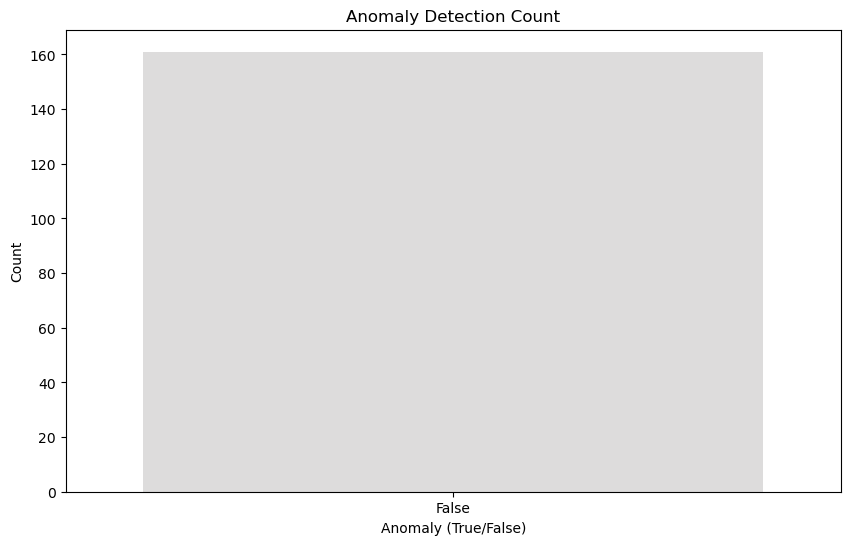

In [39]:
plt.figure(figsize=(10, 6))
sns.countplot(x=df['anomaly'], palette='coolwarm')
plt.title('Anomaly Detection Count')
plt.xlabel('Anomaly (True/False)')
plt.ylabel('Count')
plt.show()

## Word Cloud for Most Common Words (Lemmatized or Clean Text)

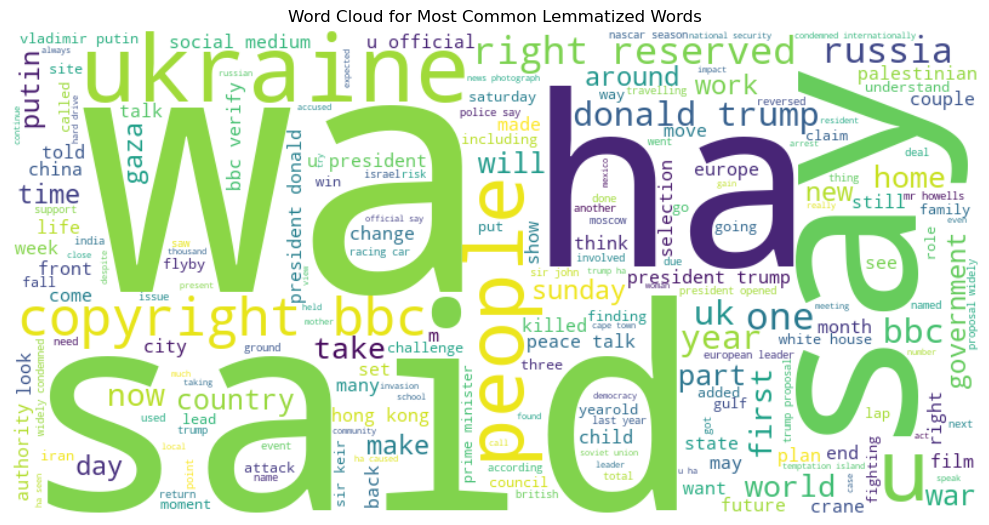

In [41]:
from wordcloud import WordCloud

# Combine all lemmatized text into one string
text = ' '.join(df['lemmatized'])

# Generate a word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

# Plot the word cloud
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title('Word Cloud for Most Common Lemmatized Words')
plt.axis('off')
plt.tight_layout()
plt.show()

##  Visualizing the topic distribution from BERTopic

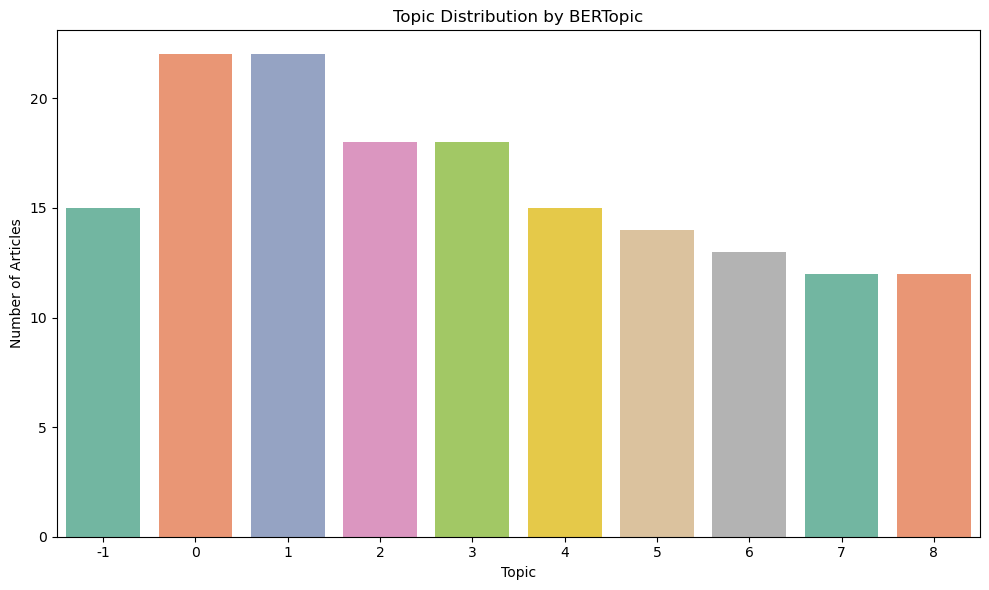

In [43]:
plt.figure(figsize=(10, 6))
sns.countplot(x='bertopic_topic', data=df, palette='Set2')
plt.title('Topic Distribution by BERTopic')
plt.xlabel('Topic')
plt.ylabel('Number of Articles')
plt.tight_layout()
plt.show()

##  Visualizing the overlap of topics between BERTopic and LDA using a scatter plot

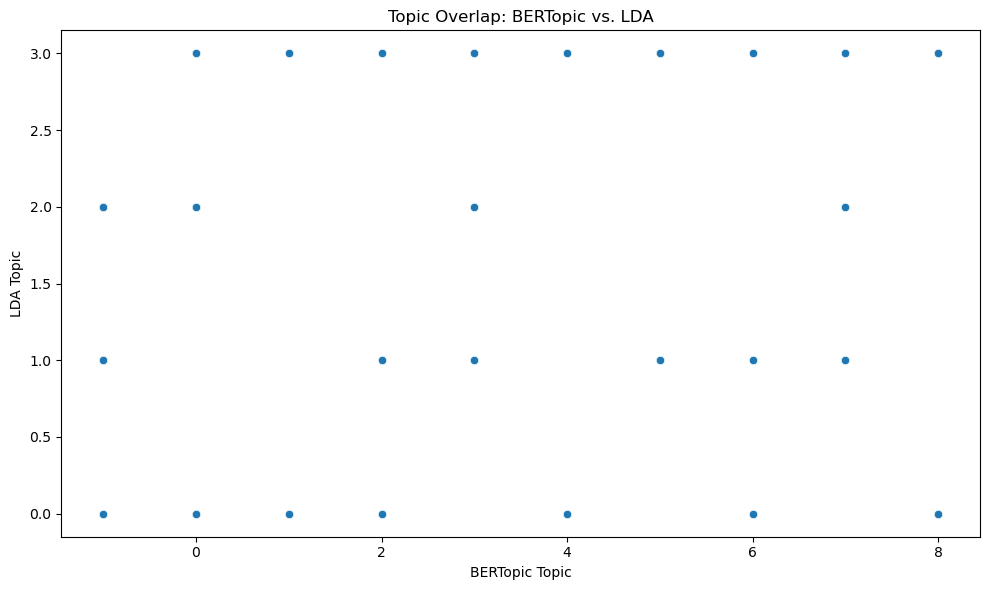

In [45]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='bertopic_topic', y='lda_topic', data=df, palette='viridis')
plt.title('Topic Overlap: BERTopic vs. LDA')
plt.xlabel('BERTopic Topic')
plt.ylabel('LDA Topic')
plt.tight_layout()
plt.show()

## Sentiment-based topic distribution plot

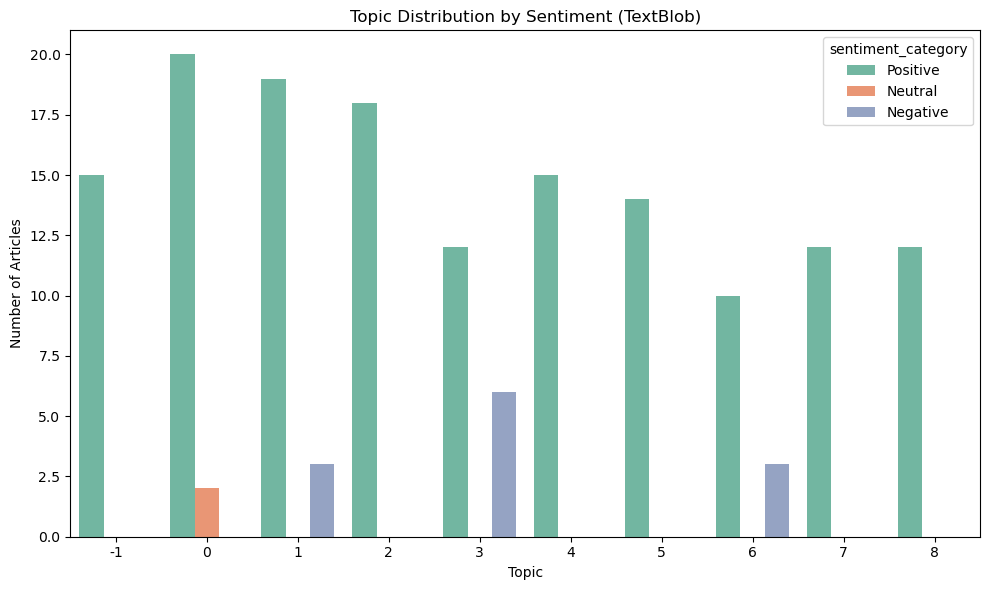

In [47]:
# Creating a sentiment-based topic distribution plot
df['sentiment_category'] = df['tb_sentiment'].apply(lambda x: 'Positive' if x.polarity > 0 else ('Negative' if x.polarity < 0 else 'Neutral'))

plt.figure(figsize=(10, 6))
sns.countplot(x='bertopic_topic', hue='sentiment_category', data=df, palette='Set2')
plt.title('Topic Distribution by Sentiment (TextBlob)')
plt.xlabel('Topic')
plt.ylabel('Number of Articles')
plt.tight_layout()
plt.show()

## Coherence matrix for LDA topics

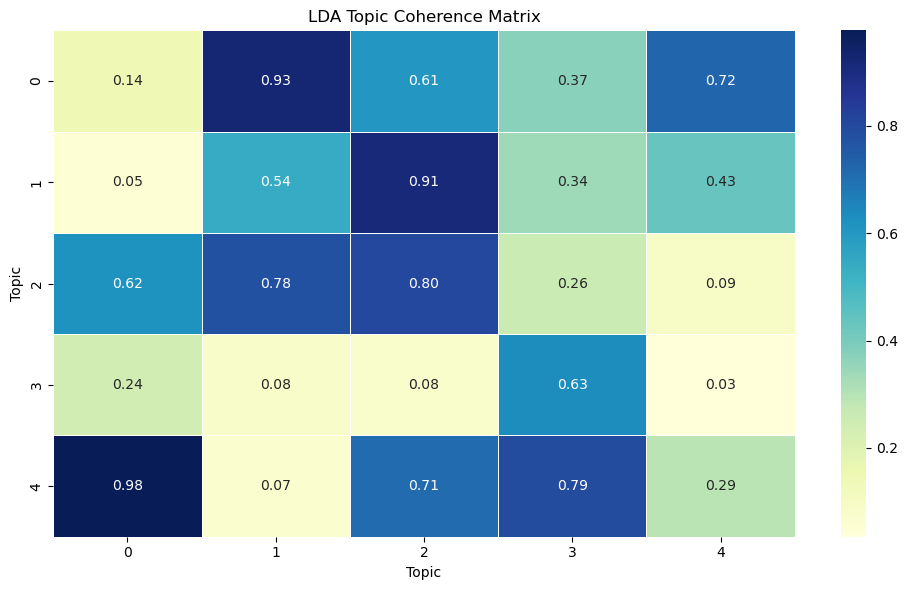

In [49]:
# Assuming the coherence matrix for LDA topics
# Creating a random coherence matrix for demonstration, replace this with your actual matrix
lda_coherence_matrix = np.random.rand(5, 5)

plt.figure(figsize=(10, 6))
sns.heatmap(lda_coherence_matrix, annot=True, cmap='YlGnBu', fmt='.2f', linewidths=0.5)
plt.title('LDA Topic Coherence Matrix')
plt.xlabel('Topic')
plt.ylabel('Topic')
plt.tight_layout()
plt.show()

## Distribution of Article Lengths

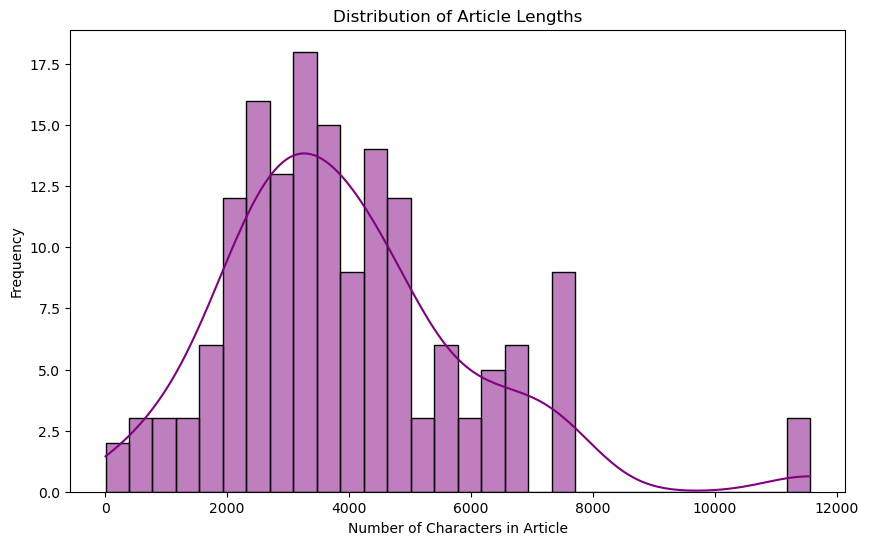

In [51]:
df['article_length'] = df['clean_text'].dropna().apply(len)

plt.figure(figsize=(10, 6))
sns.histplot(df['article_length'], bins=30, kde=True, color='purple')
plt.title('Distribution of Article Lengths')
plt.xlabel('Number of Characters in Article')
plt.ylabel('Frequency')
plt.show()

## Bar Plot of Most Frequent Named Entities

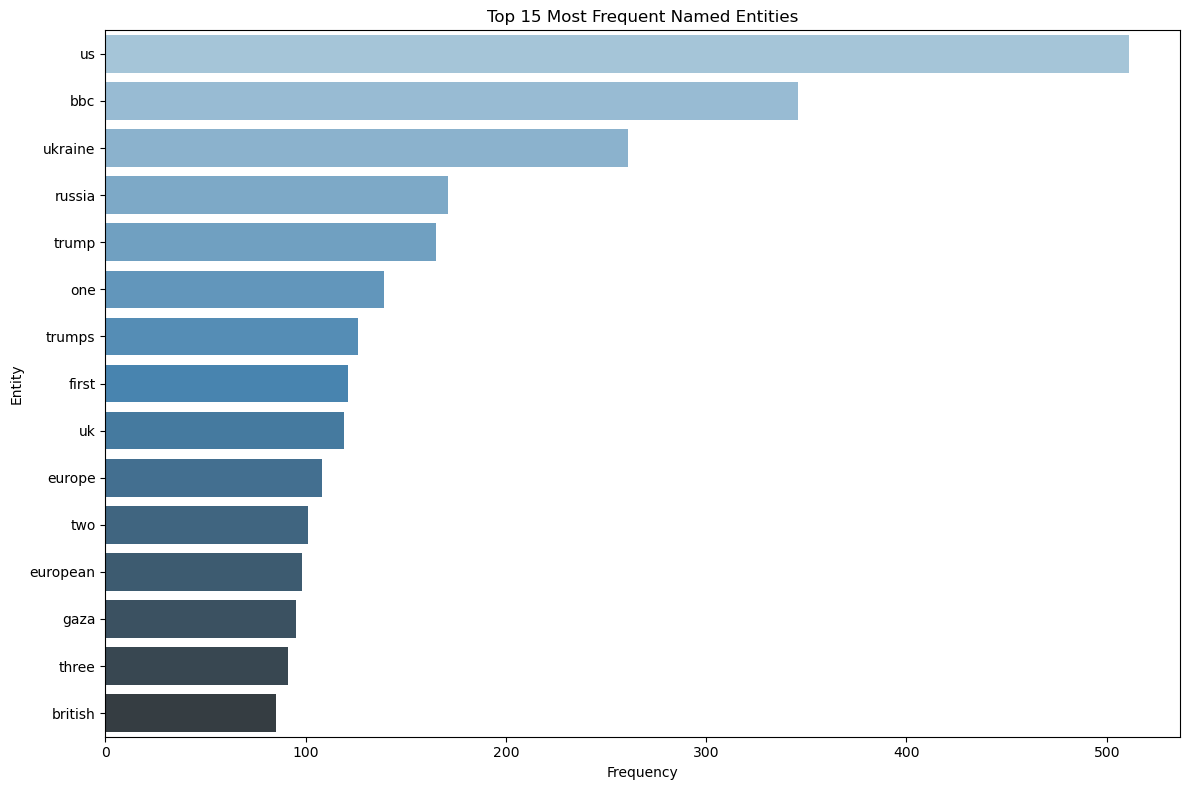

In [53]:
def safe_eval(value):
    """Safely evaluate a string representation of a list."""
    try:
        return ast.literal_eval(value) if isinstance(value, str) else value
    except (SyntaxError, ValueError):
        return []  # Return an empty list if conversion fails

# Apply safe_eval to the entities column
df['entities'] = df['entities'].apply(safe_eval)

# Flatten entity lists and count occurrences
all_entities = [entity[0] for entities_list in df['entities'].dropna() for entity in entities_list if isinstance(entity, tuple)]
entity_counts = Counter(all_entities)
common_entities = entity_counts.most_common(15)

# Plot the top 15 most frequent named entities
plt.figure(figsize=(12, 8))
sns.barplot(x=[count for _, count in common_entities], y=[entity for entity, _ in common_entities], palette='Blues_d')
plt.title('Top 15 Most Frequent Named Entities')
plt.xlabel('Frequency')
plt.ylabel('Entity')
plt.tight_layout()
plt.show()